# DeepLabV3+ Training Pipeline for Multiclass Stroke Biomarker Segmentation

This notebook trains a **DeepLabV3+ CNN with a ResNet-50 backbone** for multiclass brain CT segmentation using the same data, augmentation, loss, metric, checkpointing, and evaluation workflow as the UCTransNet pipeline.

The pipeline includes:

1. Install dependencies
2. Configure paths, classes, and training parameters
3. Discover, split, validate, and audit the dataset
4. Measure class representation and build class-aware augmentation
5. Create weighted sampling, datasets, and loaders
6. Build and verify DeepLabV3+
7. Configure weighted cross-entropy plus multiclass Dice loss
8. Train with AdamW, step-based warmup/cosine scheduling, AMP, and early stopping
9. Save and resume checkpoints
10. Evaluate the held-out test set and visualize biomarker predictions

## Expected dataset layout

Either provide pre-split data:

```text
stroke_dataset/
├── train/
│   ├── images/
│   └── masks/
├── val/
│   ├── images/
│   └── masks/
└── test/
    ├── images/
    └── masks/
```

or an unsplit dataset:

```text
stroke_dataset/
├── images/
└── masks/
```

Images and masks must share the same filename stem. Masks must contain integer class IDs `0–15`, where `0` is background.

> **Model note:** DeepLabV3+ combines atrous spatial pyramid pooling with a low-level decoder. The notebook can initialize the ResNet-50 encoder from ImageNet weights when internet access is available and automatically falls back to random initialization if the download is unavailable.

## 1. Install dependencies

In [1]:
# Run once in a fresh notebook environment, then restart the kernel if required.
%pip install -q \
  torch torchvision \
  numpy pandas matplotlib pillow opencv-python-headless \
  albumentations scikit-learn scipy tqdm tensorboard

Note: you may need to restart the kernel to use updated packages.


## 2. Imports and environment checks

In [2]:
from __future__ import annotations

import hashlib
import json
import math
import os
import pickle
import random
import subprocess
import sys
import time
import warnings

from collections import Counter, defaultdict
from dataclasses import asdict, dataclass, is_dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Set, Tuple, Union

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from albumentations.pytorch import ToTensorV2
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch
from PIL import Image
from scipy.ndimage import binary_erosion, distance_transform_edt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision.models import ResNet50_Weights, resnet50
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13
PyTorch: 2.12.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5090


## 3. Central configuration

In [3]:
CLASS_NAMES: Dict[int, str] = {
    0: "background",
    1: "cerebral_edema",
    2: "cortical_involvement",
    3: "hemorrhagic_transformation",
    4: "hyperdense_artery_sign",
    5: "intracerebral_hemorrhage",
    6: "intraventricular_hemorrhage",
    7: "ischemic_infarct",
    8: "large_lesion_1_3_mca_territory",
    9: "large_vessel_occlusion",
    10: "mass_effect",
    11: "midline_shift",
    12: "multiple_lesions",
    13: "spontaneous_asdh",
    14: "subarachnoid_extension",
    15: "temporal_lobe_involvement",
}


@dataclass(frozen=True)
class Config:
    # Paths
    dataset_root: str = "stroke_dataset"
    output_root: str = "outputs/deeplabv3plus_stroke"

    # Dataset and splitting
    train_ratio: float = 0.70
    val_ratio: float = 0.15
    test_ratio: float = 0.15
    image_size: int = 256
    num_classes: int = 16
    ignore_index: int = 255
    seed: int = 42

    image_extensions: Tuple[str, ...] = (
        ".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"
    )
    mask_extensions: Tuple[str, ...] = (
        ".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"
    )

    # Example:
    # patient001_slice003 with delimiter "_slice" -> patient001
    patient_id_delimiter: Optional[str] = None

    # DeepLabV3+ architecture
    input_channels: int = 3
    backbone_pretrained: bool = True
    freeze_backbone_batchnorm: bool = True
    aspp_channels: int = 256
    aspp_rates: Tuple[int, int, int] = (6, 12, 18)
    low_level_channels: int = 48
    decoder_channels: int = 256
    classifier_dropout: float = 0.10
    group_norm_max_groups: int = 32

    # Optional matching-layer warm start. Leave None to use
    # ImageNet initialization or train from scratch.
    warmstart_checkpoint: Optional[str] = None

    # Class-aware augmentation
    use_class_aware_sampling: bool = True
    use_class_centered_crops: bool = True
    max_sampling_multiplier: float = 6.0
    background_only_sample_weight: float = 0.60
    class_crop_probability: float = 0.75
    minimum_crop_size: int = 192
    maximum_crop_size: int = 320

    # Training
    epochs: int = 150
    batch_size: int = 4
    num_workers: int = 4
    learning_rate: float = 5e-5
    min_learning_rate: float = 5e-7
    weight_decay: float = 1e-4
    warmup_epochs: int = 5
    early_stopping_patience: int = 20
    gradient_clip_norm: float = 1.0
    amp: bool = True

    # Loss
    ce_weight: float = 0.5
    dice_weight: float = 0.5
    class_weight_min: float = 0.10
    class_weight_max: float = 3.00

    # Runtime
    deterministic: bool = True
    pin_memory: bool = True
    persistent_workers: bool = True


CFG = Config()
ALLOWED_CLASS_IDS: Set[int] = set(range(CFG.num_classes))

assert set(CLASS_NAMES) == ALLOWED_CLASS_IDS
assert math.isclose(CFG.train_ratio + CFG.val_ratio + CFG.test_ratio, 1.0)
assert CFG.input_channels == 3, "The ResNet-50 backbone expects three input channels."
assert CFG.image_size % 16 == 0, "DeepLabV3+ input size should be divisible by 16."

DATASET_ROOT = Path(CFG.dataset_root).resolve()
OUTPUT_ROOT = Path(CFG.output_root).resolve()
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
LOG_DIR = OUTPUT_ROOT / "logs"
PREDICTION_DIR = OUTPUT_ROOT / "predictions"

for directory in (OUTPUT_ROOT, CHECKPOINT_DIR, LOG_DIR, PREDICTION_DIR):
    directory.mkdir(parents=True, exist_ok=True)

with (OUTPUT_ROOT / "config.json").open("w", encoding="utf-8") as file:
    json.dump(asdict(CFG), file, indent=2)

print(json.dumps(asdict(CFG), indent=2))

{
  "dataset_root": "stroke_dataset",
  "output_root": "outputs/deeplabv3plus_stroke",
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "image_size": 256,
  "num_classes": 16,
  "ignore_index": 255,
  "seed": 42,
  "image_extensions": [
    ".png",
    ".jpg",
    ".jpeg",
    ".tif",
    ".tiff",
    ".bmp"
  ],
  "mask_extensions": [
    ".png",
    ".jpg",
    ".jpeg",
    ".tif",
    ".tiff",
    ".bmp"
  ],
  "patient_id_delimiter": null,
  "input_channels": 3,
  "backbone_pretrained": true,
  "freeze_backbone_batchnorm": true,
  "aspp_channels": 256,
  "aspp_rates": [
    6,
    12,
    18
  ],
  "low_level_channels": 48,
  "decoder_channels": 256,
  "classifier_dropout": 0.1,
  "group_norm_max_groups": 32,
  "warmstart_checkpoint": null,
  "use_class_aware_sampling": true,
  "use_class_centered_crops": true,
  "max_sampling_multiplier": 6.0,
  "background_only_sample_weight": 0.6,
  "class_crop_probability": 0.75,
  "minimum_crop_size": 192,
  "maximum_crop_siz

## 4. Reproducibility and device setup

In [4]:
def seed_everything(seed: int, deterministic: bool = True) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except TypeError:
            torch.use_deterministic_algorithms(True)
    else:
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False


seed_everything(CFG.seed, CFG.deterministic)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 5. Define the DeepLabV3+ CNN architecture

In [5]:
def compatible_group_count(
    channels: int,
    maximum_groups: int,
) -> int:
    """Choose the largest valid GroupNorm group count."""
    for groups in range(min(maximum_groups, channels), 0, -1):
        if channels % groups == 0:
            return groups
    return 1


def group_norm(
    channels: int,
    maximum_groups: int,
) -> nn.GroupNorm:
    return nn.GroupNorm(
        compatible_group_count(channels, maximum_groups),
        channels,
    )


class ConvNormReLU(nn.Sequential):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        padding: int = 0,
        dilation: int = 1,
        maximum_groups: int = 32,
    ) -> None:
        super().__init__(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                padding=padding,
                dilation=dilation,
                bias=False,
            ),
            group_norm(out_channels, maximum_groups),
            nn.ReLU(inplace=True),
        )


class ASPPPooling(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        maximum_groups: int,
    ) -> None:
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.project = ConvNormReLU(
            in_channels,
            out_channels,
            kernel_size=1,
            maximum_groups=maximum_groups,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        spatial_size = x.shape[-2:]
        x = self.pool(x)
        x = self.project(x)

        return F.interpolate(
            x,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )


class ASPP(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        atrous_rates: Sequence[int],
        maximum_groups: int,
        dropout: float,
    ) -> None:
        super().__init__()

        branches: List[nn.Module] = [
            ConvNormReLU(
                in_channels,
                out_channels,
                kernel_size=1,
                maximum_groups=maximum_groups,
            )
        ]

        for rate in atrous_rates:
            branches.append(
                ConvNormReLU(
                    in_channels,
                    out_channels,
                    kernel_size=3,
                    padding=int(rate),
                    dilation=int(rate),
                    maximum_groups=maximum_groups,
                )
            )

        branches.append(
            ASPPPooling(
                in_channels,
                out_channels,
                maximum_groups,
            )
        )

        self.branches = nn.ModuleList(branches)

        self.project = nn.Sequential(
            ConvNormReLU(
                out_channels * len(branches),
                out_channels,
                kernel_size=1,
                maximum_groups=maximum_groups,
            ),
            nn.Dropout(p=float(dropout)),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = [
            branch(x)
            for branch in self.branches
        ]

        return self.project(
            torch.cat(features, dim=1)
        )


class DeepLabV3Plus(nn.Module):
    """
    DeepLabV3+ with a dilated ResNet-50 encoder, ASPP, and
    a low-level feature decoder.
    """

    def __init__(
        self,
        num_classes: int,
        pretrained_backbone: bool = True,
        freeze_backbone_batchnorm: bool = True,
        aspp_channels: int = 256,
        aspp_rates: Sequence[int] = (6, 12, 18),
        low_level_channels: int = 48,
        decoder_channels: int = 256,
        dropout: float = 0.10,
        maximum_groups: int = 32,
    ) -> None:
        super().__init__()

        self.freeze_backbone_batchnorm = bool(
            freeze_backbone_batchnorm
        )

        requested_weights = (
            ResNet50_Weights.DEFAULT
            if pretrained_backbone
            else None
        )

        try:
            backbone = resnet50(
                weights=requested_weights,
                replace_stride_with_dilation=[False, False, True],
            )
            self.backbone_pretrained_loaded = (
                requested_weights is not None
            )
        except Exception as error:
            warnings.warn(
                "ImageNet backbone weights could not be loaded. "
                f"Falling back to random initialization. Reason: {error}"
            )
            backbone = resnet50(
                weights=None,
                replace_stride_with_dilation=[False, False, True],
            )
            self.backbone_pretrained_loaded = False

        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
        )
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.aspp = ASPP(
            in_channels=2048,
            out_channels=aspp_channels,
            atrous_rates=aspp_rates,
            maximum_groups=maximum_groups,
            dropout=dropout,
        )

        self.low_level_projection = ConvNormReLU(
            in_channels=256,
            out_channels=low_level_channels,
            kernel_size=1,
            maximum_groups=maximum_groups,
        )

        self.decoder = nn.Sequential(
            ConvNormReLU(
                aspp_channels + low_level_channels,
                decoder_channels,
                kernel_size=3,
                padding=1,
                maximum_groups=maximum_groups,
            ),
            ConvNormReLU(
                decoder_channels,
                decoder_channels,
                kernel_size=3,
                padding=1,
                maximum_groups=maximum_groups,
            ),
            nn.Dropout2d(p=float(dropout)),
        )

        self.classifier = nn.Conv2d(
            decoder_channels,
            num_classes,
            kernel_size=1,
        )

        nn.init.kaiming_normal_(
            self.classifier.weight,
            mode="fan_out",
            nonlinearity="relu",
        )
        if self.classifier.bias is not None:
            nn.init.zeros_(self.classifier.bias)

    def _set_backbone_batchnorm_eval(self) -> None:
        for module in (
            self.stem,
            self.layer1,
            self.layer2,
            self.layer3,
            self.layer4,
        ):
            for child in module.modules():
                if isinstance(
                    child,
                    nn.modules.batchnorm._BatchNorm,
                ):
                    child.eval()

    def train(self, mode: bool = True):
        super().train(mode)

        if mode and self.freeze_backbone_batchnorm:
            self._set_backbone_batchnorm_eval()

        return self

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        input_size = x.shape[-2:]

        x = self.stem(x)
        low_level = self.layer1(x)

        x = self.layer2(low_level)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.aspp(x)

        low_level = self.low_level_projection(
            low_level
        )

        x = F.interpolate(
            x,
            size=low_level.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        x = torch.cat(
            [x, low_level],
            dim=1,
        )

        x = self.decoder(x)
        x = self.classifier(x)

        return F.interpolate(
            x,
            size=input_size,
            mode="bilinear",
            align_corners=False,
        )


print("DeepLabV3+ architecture definition succeeded.")

DeepLabV3+ architecture definition succeeded.


## 6. Dataset discovery and patient-level splitting

In [7]:
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence


@dataclass(frozen=True)
class Sample:
    sample_id: str
    image_path: str
    mask_path: str
    patient_id: str


def infer_patient_id(
    stem: str,
    delimiter: Optional[str],
) -> str:
    if delimiter and delimiter in stem:
        return stem.split(delimiter, 1)[0]

    return stem


def should_ignore_file(path: Path) -> bool:
    """
    Ignore temporary, hidden, backup, and checkpoint files.
    """

    stem = path.stem.lower()
    filename = path.name.lower()

    # Ignore files inside hidden/checkpoint directories.
    if any(
        part.lower() in {
            ".ipynb_checkpoints",
            "__pycache__",
        }
        for part in path.parts
    ):
        return True

    # Ignore hidden files.
    if filename.startswith("."):
        return True

    # Ignore common temporary or backup files.
    ignored_stem_endings = (
        "-checkpoint",
        "_checkpoint",
        "-backup",
        "_backup",
        "-copy",
        "_copy",
    )

    if stem.endswith(ignored_stem_endings):
        return True

    if filename.startswith("~$"):
        return True

    return False


def indexed_files(
    folder: Path,
    extensions: Sequence[str],
) -> Dict[str, Path]:
    """
    Index supported files by filename stem while excluding
    temporary and checkpoint files.
    """

    folder = Path(folder)

    if not folder.exists():
        raise FileNotFoundError(
            f"Missing folder: {folder.resolve()}"
        )

    supported_extensions = {
        extension.lower()
        if extension.startswith(".")
        else f".{extension.lower()}"
        for extension in extensions
    }

    files = []

    for path in folder.rglob("*"):
        if not path.is_file():
            continue

        if path.suffix.lower() not in supported_extensions:
            continue

        if should_ignore_file(path):
            print(
                f"Ignoring temporary/checkpoint file: {path}"
            )
            continue

        files.append(path)

    index: Dict[str, Path] = {}

    for path in files:
        stem = path.stem

        if stem in index:
            raise ValueError(
                f"Duplicate filename stem '{stem}' in {folder}:\n"
                f"First file:  {index[stem]}\n"
                f"Second file: {path}"
            )

        index[stem] = path

    if not index:
        raise RuntimeError(
            f"No supported files found in {folder.resolve()}"
        )

    return index


def pair_folder(
    image_dir: Path,
    mask_dir: Path,
    strict: bool = True,
) -> List[Sample]:
    """
    Pair images and masks using identical filename stems.

    strict=True:
        Raise an error when genuine unmatched files exist.

    strict=False:
        Warn about unmatched files and use only valid pairs.
    """

    images = indexed_files(
        image_dir,
        CFG.image_extensions,
    )

    masks = indexed_files(
        mask_dir,
        CFG.mask_extensions,
    )

    image_stems = set(images)
    mask_stems = set(masks)

    missing_masks = sorted(
        image_stems - mask_stems
    )

    missing_images = sorted(
        mask_stems - image_stems
    )

    if missing_masks or missing_images:
        message = (
            "Image-mask pairing mismatch.\n"
            f"Missing masks for {len(missing_masks)} images: "
            f"{missing_masks[:20]}\n"
            f"Missing images for {len(missing_images)} masks: "
            f"{missing_images[:20]}"
        )

        if strict:
            raise ValueError(message)

        warnings.warn(
            message
            + "\nOnly correctly paired files will be used.",
            category=UserWarning,
        )

    paired_stems = sorted(
        image_stems & mask_stems
    )

    if not paired_stems:
        raise RuntimeError(
            f"No valid image-mask pairs found between:\n"
            f"Images: {image_dir.resolve()}\n"
            f"Masks:  {mask_dir.resolve()}"
        )

    samples = [
        Sample(
            sample_id=stem,
            image_path=str(images[stem]),
            mask_path=str(masks[stem]),
            patient_id=infer_patient_id(
                stem,
                CFG.patient_id_delimiter,
            ),
        )
        for stem in paired_stems
    ]

    print(
        f"Paired {len(samples)} samples from "
        f"{image_dir.parent.name}"
    )

    return samples


def locate_split_dir(root: Path, candidates: Sequence[str]) -> Optional[Path]:
    for name in candidates:
        candidate = root / name
        if candidate.exists():
            return candidate
    return None


def discover_dataset(
    root: Path,
) -> Dict[str, List[Sample]]:
    train_dir = locate_split_dir(
        root,
        ("train", "training"),
    )

    val_dir = locate_split_dir(
        root,
        ("val", "validation", "valid"),
    )

    test_dir = locate_split_dir(
        root,
        ("test", "testing"),
    )

    if train_dir and val_dir and test_dir:
        return {
            "train": pair_folder(
                train_dir / "images",
                train_dir / "masks",
                strict=True,
            ),
            "val": pair_folder(
                val_dir / "images",
                val_dir / "masks",
                strict=True,
            ),
            "test": pair_folder(
                test_dir / "images",
                test_dir / "masks",
                strict=True,
            ),
        }

    image_dir = root / "images"
    mask_dir = root / "masks"

    if image_dir.exists() and mask_dir.exists():
        return {
            "all": pair_folder(
                image_dir,
                mask_dir,
                strict=True,
            )
        }

    raise FileNotFoundError(
        f"Could not recognize dataset layout under {root}.\n"
        "Expected split folders containing images/ and masks/, "
        "or top-level images/ and masks/."
    )


def split_unsplit_samples(samples: List[Sample]) -> Dict[str, List[Sample]]:
    groups: Dict[str, List[Sample]] = defaultdict(list)
    for sample in samples:
        groups[sample.patient_id].append(sample)

    patient_ids = sorted(groups)
    if len(patient_ids) < 3:
        raise ValueError("At least three independent patients/cases are required.")

    train_ids, temporary_ids = train_test_split(
        patient_ids,
        test_size=CFG.val_ratio + CFG.test_ratio,
        random_state=CFG.seed,
        shuffle=True,
    )

    relative_test_ratio = CFG.test_ratio / (CFG.val_ratio + CFG.test_ratio)
    val_ids, test_ids = train_test_split(
        temporary_ids,
        test_size=relative_test_ratio,
        random_state=CFG.seed,
        shuffle=True,
    )

    def expand(ids: Sequence[str]) -> List[Sample]:
        return sorted(
            [sample for patient_id in ids for sample in groups[patient_id]],
            key=lambda sample: sample.sample_id,
        )

    return {
        "train": expand(train_ids),
        "val": expand(val_ids),
        "test": expand(test_ids),
    }


raw_splits = discover_dataset(DATASET_ROOT)
splits = (
    split_unsplit_samples(raw_splits["all"])
    if "all" in raw_splits
    else raw_splits
)

split_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "samples": len(samples),
            "patients_or_cases": len({sample.patient_id for sample in samples}),
            "sample_ratio": len(samples) / sum(len(values) for values in splits.values()),
        }
        for split_name, samples in splits.items()
    ]
)

display(split_summary)

Ignoring temporary/checkpoint file: /workspace/bash_phd/ml_pipeline/stroke_dataset/images/.ipynb_checkpoints/16239-checkpoint.png
Paired 941 samples from stroke_dataset


,split,samples,patients_or_cases,sample_ratio
0,train,658,658,0.699256
1,val,141,141,0.149841
2,test,142,142,0.150903


## 7. Read and validate images and multiclass masks

In [8]:
def sha256_file(path: str, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_image(path: str) -> np.ndarray:
    image = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if image is None:
        raise ValueError(f"Unreadable image: {path}")

    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image


def read_mask(path: str) -> np.ndarray:
    mask = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if mask is None:
        raise ValueError(f"Unreadable mask: {path}")

    if mask.ndim == 3:
        channels_identical = (
            np.array_equal(mask[..., 0], mask[..., 1])
            and np.array_equal(mask[..., 1], mask[..., 2])
        )
        if not channels_identical:
            raise ValueError(
                f"RGB mask has non-identical channels: {path}. "
                "Convert colour-coded masks to integer class IDs first."
            )
        mask = mask[..., 0]

    if mask.ndim != 2:
        raise ValueError(f"Expected a 2D mask, received {mask.shape}: {path}")

    return mask


def normalize_multiclass_mask(
    mask: np.ndarray,
    allowed_class_ids: Optional[Set[int]] = None,
) -> np.ndarray:
    if np.issubdtype(mask.dtype, np.floating):
        if not np.allclose(mask, np.round(mask)):
            raise ValueError("Mask contains non-integer floating-point values.")
        mask = np.round(mask)

    mask = mask.astype(np.int64)
    values = {int(value) for value in np.unique(mask)}

    if min(values, default=0) < 0:
        raise ValueError(f"Negative class IDs found: {sorted(values)}")

    if allowed_class_ids is not None:
        unexpected = values - allowed_class_ids
        if unexpected:
            raise ValueError(
                f"Unexpected class IDs {sorted(unexpected)}. "
                f"Allowed IDs: {sorted(allowed_class_ids)}"
            )

    return mask


def validate_dataset(
    splits: Dict[str, List[Sample]],
    allowed_class_ids: Set[int],
    raise_on_duplicate: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    patient_sets = {
        split_name: {sample.patient_id for sample in samples}
        for split_name, samples in splits.items()
    }

    for left, right in (("train", "val"), ("train", "test"), ("val", "test")):
        overlap = patient_sets.get(left, set()) & patient_sets.get(right, set())
        if overlap:
            raise ValueError(
                f"Patient/case leakage between {left} and {right}: "
                f"{sorted(overlap)[:10]}"
            )

    hash_to_sample: Dict[str, Dict[str, str]] = {}
    duplicates: List[Dict[str, str]] = []
    quality_rows: List[Dict[str, float]] = []

    for split_name, samples in splits.items():
        total_pixels = 0
        foreground_pixels = 0
        empty_masks = 0

        for sample in tqdm(samples, desc=f"Validating {split_name}"):
            image = read_image(sample.image_path)
            mask = normalize_multiclass_mask(
                read_mask(sample.mask_path),
                allowed_class_ids,
            )

            if image.shape[:2] != mask.shape[:2]:
                raise ValueError(
                    f"Shape mismatch for {sample.sample_id}: "
                    f"image={image.shape}, mask={mask.shape}"
                )

            image_hash = sha256_file(sample.image_path)
            previous = hash_to_sample.get(image_hash)

            if previous is not None and previous["split"] != split_name:
                record = {
                    "image_hash": image_hash,
                    "first_split": previous["split"],
                    "first_sample_id": previous["sample_id"],
                    "first_image_path": previous["image_path"],
                    "duplicate_split": split_name,
                    "duplicate_sample_id": sample.sample_id,
                    "duplicate_image_path": sample.image_path,
                }
                duplicates.append(record)

                message = (
                    f"Duplicate image content across {previous['split']} and "
                    f"{split_name}: {sample.image_path}"
                )
                if raise_on_duplicate:
                    raise ValueError(message)
                warnings.warn(message)
            else:
                hash_to_sample[image_hash] = {
                    "split": split_name,
                    "sample_id": sample.sample_id,
                    "image_path": sample.image_path,
                }

            foreground = int(np.count_nonzero(mask != 0))
            foreground_pixels += foreground
            total_pixels += int(mask.size)
            empty_masks += int(foreground == 0)

        number_of_samples = len(samples)
        quality_rows.append(
            {
                "split": split_name,
                "samples": number_of_samples,
                "empty_masks": empty_masks,
                "empty_mask_pct": (
                    100 * empty_masks / number_of_samples
                    if number_of_samples else 0.0
                ),
                "foreground_pixel_pct": (
                    100 * foreground_pixels / total_pixels
                    if total_pixels else 0.0
                ),
            }
        )

    return pd.DataFrame(quality_rows), pd.DataFrame(duplicates)


quality_report, duplicate_report = validate_dataset(
    splits=splits,
    allowed_class_ids=ALLOWED_CLASS_IDS,
    raise_on_duplicate=False,
)

display(quality_report)
display(duplicate_report)

Validating train:   0%|          | 0/658 [00:00<?, ?it/s]

Validating val:   0%|          | 0/141 [00:00<?, ?it/s]

/tmp/ipykernel_2527/4147902738.py:130: UserWarning: Duplicate image content across train and val: /workspace/bash_phd/ml_pipeline/stroke_dataset/images/slice_0206.png
  warnings.warn(message)


Validating test:   0%|          | 0/142 [00:00<?, ?it/s]

,split,samples,empty_masks,empty_mask_pct,foreground_pixel_pct
0,train,658,197,29.939210,2.146531
1,val,141,33,23.404255,2.190993
2,test,142,49,34.507042,1.893318


,image_hash,first_split,first_sample_id,first_image_path,duplicate_split,duplicate_sample_id,duplicate_image_path
0,e33da9de3e699fd777f26777bd903d1d3ac15fcf97a1ea...,train,slice_0204,/workspace/bash_phd/ml_pipeline/stroke_dataset...,val,slice_0206,/workspace/bash_phd/ml_pipeline/stroke_dataset...


## 8. Measure class representation and identify train-split gaps

In [9]:
def analyse_class_representation(
    splits: Dict[str, List[Sample]],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    split_rows: List[Dict[str, Any]] = []
    overall_pixel_counts = Counter()
    overall_sample_counts = Counter()
    overall_total_pixels = 0
    overall_total_samples = 0

    for split_name, samples in splits.items():
        pixel_counts = Counter()
        sample_counts = Counter()
        total_pixels = 0

        for sample in tqdm(samples, desc=f"Analysing {split_name}"):
            mask = normalize_multiclass_mask(
                read_mask(sample.mask_path),
                ALLOWED_CLASS_IDS,
            )

            class_ids, counts = np.unique(mask, return_counts=True)
            total_pixels += int(mask.size)
            overall_total_pixels += int(mask.size)

            for class_id, count in zip(class_ids, counts):
                class_id = int(class_id)
                count = int(count)
                pixel_counts[class_id] += count
                overall_pixel_counts[class_id] += count

            for class_id in class_ids:
                class_id = int(class_id)
                sample_counts[class_id] += 1
                overall_sample_counts[class_id] += 1

        overall_total_samples += len(samples)

        for class_id in sorted(ALLOWED_CLASS_IDS):
            pixels = pixel_counts[class_id]
            present = sample_counts[class_id]

            split_rows.append(
                {
                    "split": split_name,
                    "class_id": class_id,
                    "class_name": CLASS_NAMES[class_id],
                    "pixel_count": pixels,
                    "pixel_percentage": (
                        100 * pixels / total_pixels if total_pixels else 0.0
                    ),
                    "samples_with_class": present,
                    "total_samples": len(samples),
                    "sample_presence_percentage": (
                        100 * present / len(samples) if samples else 0.0
                    ),
                    "average_pixels_when_present": (
                        pixels / present if present else 0.0
                    ),
                    "missing_from_split": present == 0,
                }
            )

    overall_rows = []
    for class_id in sorted(ALLOWED_CLASS_IDS):
        pixels = overall_pixel_counts[class_id]
        present = overall_sample_counts[class_id]

        overall_rows.append(
            {
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "pixel_count": pixels,
                "pixel_percentage": (
                    100 * pixels / overall_total_pixels
                    if overall_total_pixels else 0.0
                ),
                "samples_with_class": present,
                "total_samples": overall_total_samples,
                "sample_presence_percentage": (
                    100 * present / overall_total_samples
                    if overall_total_samples else 0.0
                ),
                "average_pixels_when_present": (
                    pixels / present if present else 0.0
                ),
                "missing_from_dataset": present == 0,
            }
        )

    return pd.DataFrame(split_rows), pd.DataFrame(overall_rows)


split_class_report, overall_class_report = analyse_class_representation(splits)

print("OVERALL CLASS REPRESENTATION")
display(overall_class_report.round(6))

print("CLASS REPRESENTATION BY SPLIT")
display(split_class_report.round(6))

train_class_report = (
    split_class_report[split_class_report["split"] == "train"]
    .sort_values("class_id")
    .reset_index(drop=True)
)

missing_train_classes = train_class_report.loc[
    (train_class_report["class_id"] != 0)
    & train_class_report["missing_from_split"],
    ["class_id", "class_name"],
]

if not missing_train_classes.empty:
    print(
        "WARNING: These foreground classes have no positive training examples. "
        "Augmentation cannot create genuine supervision for them."
    )
    display(missing_train_classes)

Analysing train:   0%|          | 0/658 [00:00<?, ?it/s]

Analysing val:   0%|          | 0/141 [00:00<?, ?it/s]

Analysing test:   0%|          | 0/142 [00:00<?, ?it/s]

OVERALL CLASS REPRESENTATION


,class_id,class_name,pixel_count,pixel_percentage,samples_with_class,total_samples,sample_presence_percentage,average_pixels_when_present,missing_from_dataset
0,0,background,241496374,97.885006,941,941,100.000000,256638.017003,False
1,1,cerebral_edema,1330813,0.539414,267,941,28.374070,4984.318352,False
2,2,cortical_involvement,75169,0.030468,55,941,5.844846,1366.709091,False
3,3,hemorrhagic_transformation,57209,0.023188,32,941,3.400638,1787.781250,False
4,4,hyperdense_artery_sign,2545,0.001032,3,941,0.318810,848.333333,False
5,5,intracerebral_hemorrhage,500958,0.203052,234,941,24.867163,2140.846154,False
6,6,intraventricular_hemorrhage,159966,0.064839,84,941,8.926674,1904.357143,False
7,7,ischemic_infarct,1281104,0.519266,387,941,41.126461,3310.346253,False
8,8,large_lesion_1_3_mca_territory,464043,0.188089,26,941,2.763018,17847.807692,False
9,9,large_vessel_occlusion,269779,0.109349,32,941,3.400638,8430.593750,False


CLASS REPRESENTATION BY SPLIT


,split,class_id,class_name,pixel_count,pixel_percentage,samples_with_class,total_samples,sample_presence_percentage,average_pixels_when_present,missing_from_split
0,train,0,background,168788184,97.853469,658,658,100.000000,256516.996960,False
1,train,1,cerebral_edema,985234,0.571181,194,658,29.483283,5078.525773,False
2,train,2,cortical_involvement,55847,0.032377,39,658,5.927052,1431.974359,False
3,train,3,hemorrhagic_transformation,45881,0.026599,24,658,3.647416,1911.708333,False
4,train,4,hyperdense_artery_sign,0,0.000000,0,658,0.000000,0.000000,True
5,train,5,intracerebral_hemorrhage,337032,0.195391,162,658,24.620061,2080.444444,False
6,train,6,intraventricular_hemorrhage,103272,0.059871,58,658,8.814590,1780.551724,False
7,train,7,ischemic_infarct,874604,0.507044,265,658,40.273556,3300.392453,False
8,train,8,large_lesion_1_3_mca_territory,362681,0.210261,19,658,2.887538,19088.473684,False
9,train,9,large_vessel_occlusion,209372,0.121382,23,658,3.495441,9103.130435,False


,class_id,class_name
4,4,hyperdense_artery_sign


### Class-coverage warning

A class with no positive example in the training split cannot be learned through augmentation. Fix such gaps by moving an **entire patient/case** into training or by collecting more examples. Never move individual slices if that creates patient leakage.

## 9. Persist the split manifest

In [10]:
manifest_rows = [
    {
        "split": split_name,
        "sample_id": sample.sample_id,
        "patient_id": sample.patient_id,
        "image_path": sample.image_path,
        "mask_path": sample.mask_path,
    }
    for split_name, samples in splits.items()
    for sample in samples
]

manifest = pd.DataFrame(manifest_rows)
manifest_path = OUTPUT_ROOT / "split_manifest.csv"
manifest.to_csv(manifest_path, index=False)
print("Saved:", manifest_path)

Saved: /workspace/bash_phd/ml_pipeline/outputs/deeplabv3plus_stroke/split_manifest.csv


## 10. Visual dataset sanity check

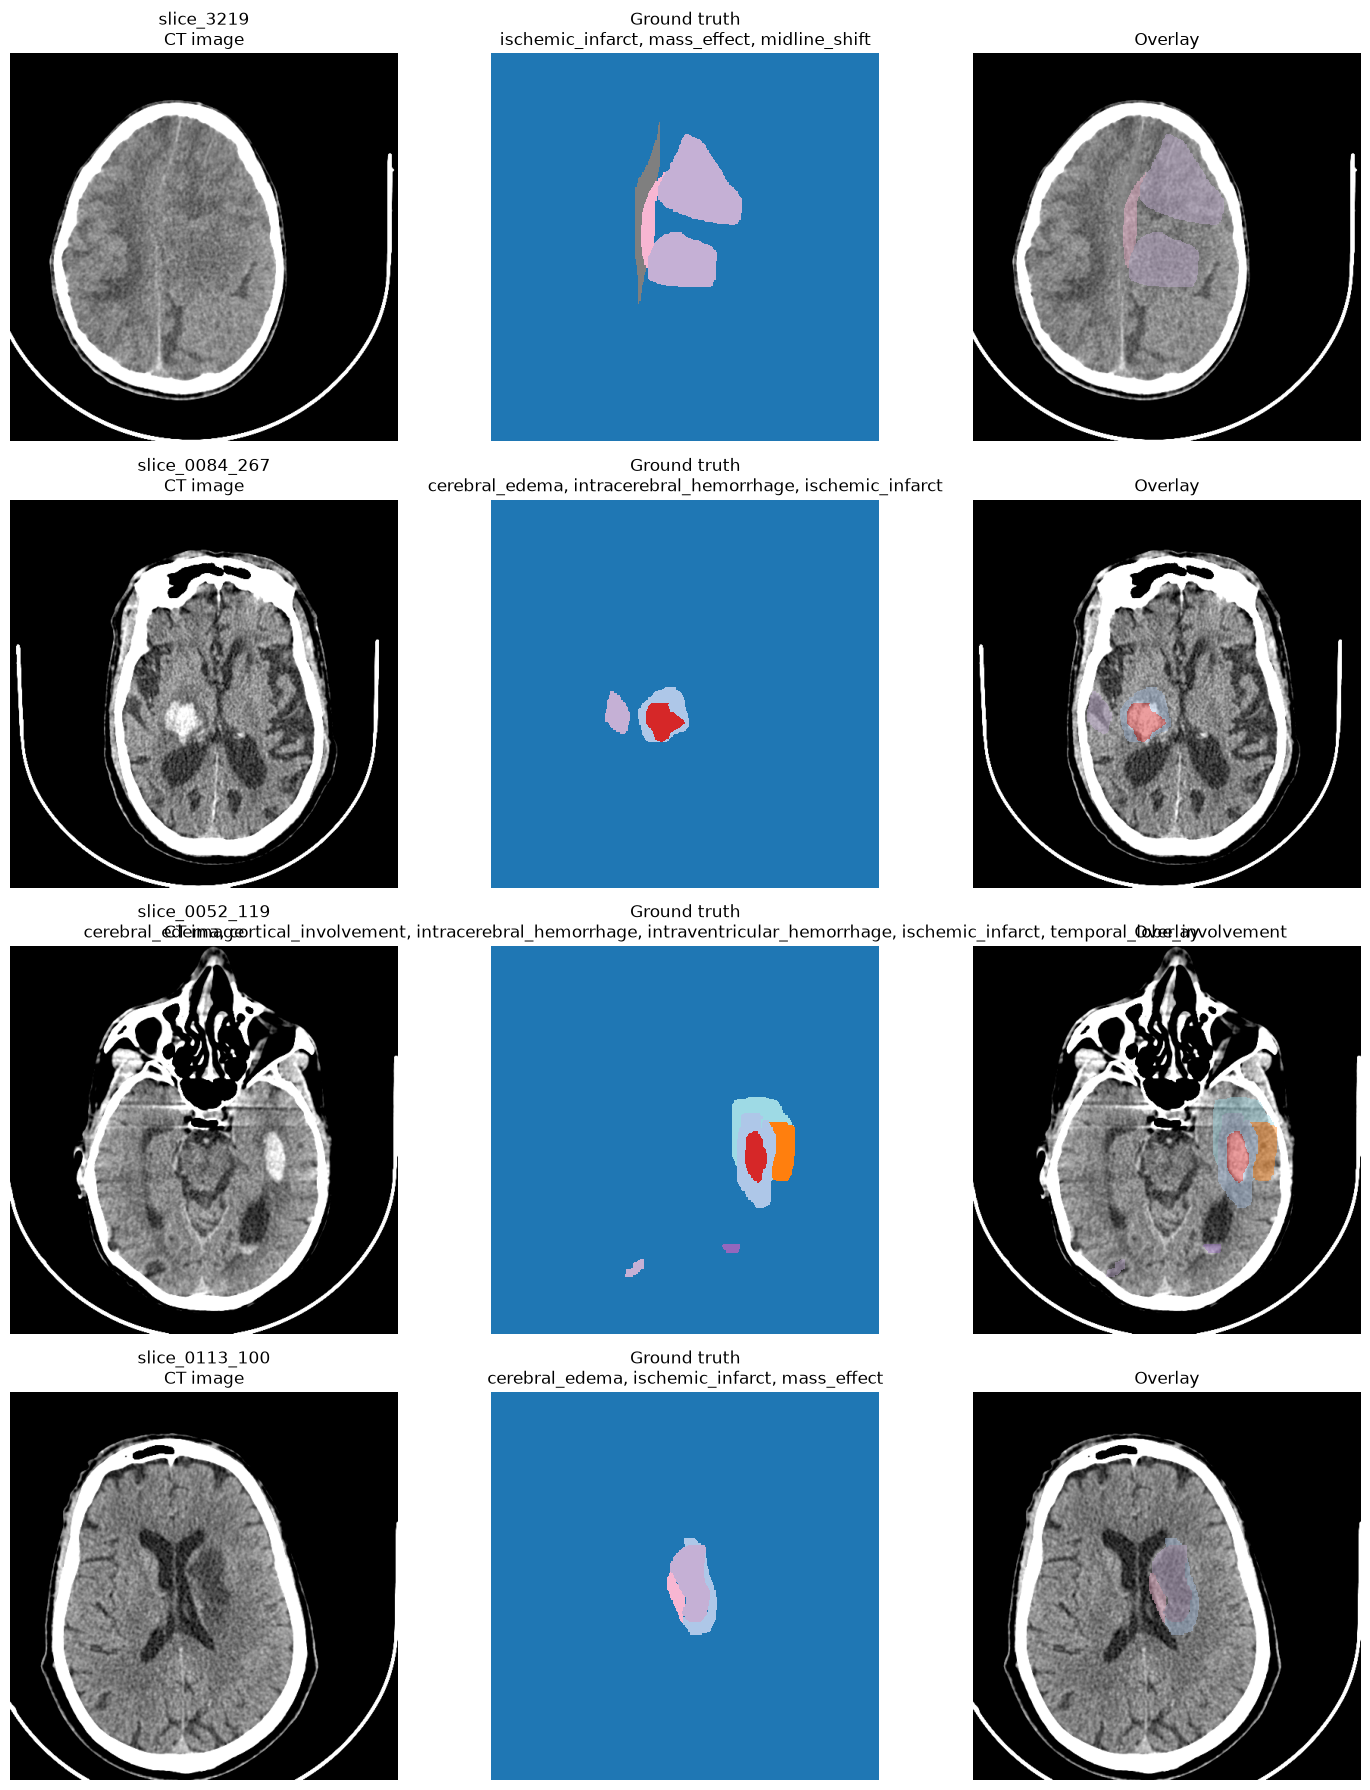

In [11]:
def show_samples(samples: Sequence[Sample], n: int = 4) -> None:
    if not samples:
        print("No samples available.")
        return

    chosen = random.sample(list(samples), k=min(n, len(samples)))
    cmap = plt.get_cmap("tab20", CFG.num_classes)
    norm = BoundaryNorm(np.arange(-0.5, CFG.num_classes + 0.5), cmap.N)

    figure, axes = plt.subplots(
        len(chosen), 3, figsize=(15, 4.5 * len(chosen)), squeeze=False
    )

    for row, sample in enumerate(chosen):
        image = read_image(sample.image_path)
        mask = normalize_multiclass_mask(
            read_mask(sample.mask_path),
            ALLOWED_CLASS_IDS,
        )

        image_cmap = "gray" if image.ndim == 2 else None
        overlay = np.ma.masked_where(mask == 0, mask)
        labels = [
            CLASS_NAMES[int(class_id)]
            for class_id in np.unique(mask)
            if int(class_id) != 0
        ]

        axes[row, 0].imshow(image, cmap=image_cmap)
        axes[row, 0].set_title(f"{sample.sample_id}\nCT image")

        axes[row, 1].imshow(mask, cmap=cmap, norm=norm, interpolation="nearest")
        axes[row, 1].set_title(
            "Ground truth\n" + (", ".join(labels) if labels else "No foreground")
        )

        axes[row, 2].imshow(image, cmap=image_cmap)
        axes[row, 2].imshow(
            overlay, cmap=cmap, norm=norm, alpha=0.45, interpolation="nearest"
        )
        axes[row, 2].set_title("Overlay")

        for axis in axes[row]:
            axis.axis("off")

    plt.tight_layout()
    plt.show()


show_samples(splits["train"], n=4)

## 11. Build data-driven class-aware sampling and cropping policies

In [12]:
TRAIN_PIXEL_COUNTS = {
    int(row.class_id): int(row.pixel_count)
    for row in train_class_report.itertuples()
}

TRAIN_SAMPLE_COUNTS = {
    int(row.class_id): int(row.samples_with_class)
    for row in train_class_report.itertuples()
}

TRAIN_AVERAGE_PIXELS = {
    int(row.class_id): float(row.average_pixels_when_present)
    for row in train_class_report.itertuples()
}

represented_foreground_counts = [
    count
    for class_id, count in TRAIN_SAMPLE_COUNTS.items()
    if class_id != 0 and count > 0
]

REFERENCE_SAMPLE_COUNT = max(represented_foreground_counts, default=1)


def class_sampling_multiplier(class_id: int) -> float:
    if class_id == 0:
        return CFG.background_only_sample_weight

    count = TRAIN_SAMPLE_COUNTS.get(class_id, 0)
    if count <= 0:
        return 0.0

    multiplier = math.sqrt(REFERENCE_SAMPLE_COUNT / count)
    return float(np.clip(multiplier, 1.0, CFG.max_sampling_multiplier))


CLASS_SAMPLING_MULTIPLIERS = {
    class_id: class_sampling_multiplier(class_id)
    for class_id in sorted(ALLOWED_CLASS_IDS)
}


def choose_crop_size(class_id: int) -> int:
    average_area = TRAIN_AVERAGE_PIXELS.get(class_id, 0.0)

    if average_area <= 2_000:
        crop_size = CFG.minimum_crop_size
    elif average_area <= 8_000:
        crop_size = CFG.image_size
    else:
        crop_size = CFG.maximum_crop_size

    crop_size = max(CFG.minimum_crop_size, min(crop_size, CFG.maximum_crop_size))
    return int(math.ceil(crop_size / 16) * 16)


policy_report = pd.DataFrame(
    [
        {
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "training_samples": TRAIN_SAMPLE_COUNTS.get(class_id, 0),
            "training_pixels": TRAIN_PIXEL_COUNTS.get(class_id, 0),
            "average_pixels_when_present": TRAIN_AVERAGE_PIXELS.get(class_id, 0.0),
            "sampling_multiplier": CLASS_SAMPLING_MULTIPLIERS[class_id],
            "target_crop_size": (
                choose_crop_size(class_id) if class_id != 0 else None
            ),
        }
        for class_id in sorted(ALLOWED_CLASS_IDS)
    ]
)

display(policy_report.round(4))

,class_id,class_name,training_samples,training_pixels,average_pixels_when_present,sampling_multiplier,target_crop_size
0,0,background,658,168788184,256516.9970,0.6000,NaN
1,1,cerebral_edema,194,985234,5078.5258,1.1688,256.0
2,2,cortical_involvement,39,55847,1431.9744,2.6067,192.0
3,3,hemorrhagic_transformation,24,45881,1911.7083,3.3229,192.0
4,4,hyperdense_artery_sign,0,0,0.0000,0.0000,192.0
5,5,intracerebral_hemorrhage,162,337032,2080.4444,1.2790,256.0
6,6,intraventricular_hemorrhage,58,103272,1780.5517,2.1375,192.0
7,7,ischemic_infarct,265,874604,3300.3925,1.0000,256.0
8,8,large_lesion_1_3_mca_territory,19,362681,19088.4737,3.7346,320.0
9,9,large_vessel_occlusion,23,209372,9103.1304,3.3944,320.0


In [13]:
def build_sample_metadata(samples: Sequence[Sample]) -> List[Dict[str, Any]]:
    metadata = []

    for index, sample in enumerate(tqdm(samples, desc="Building sample metadata")):
        mask = normalize_multiclass_mask(
            read_mask(sample.mask_path),
            ALLOWED_CLASS_IDS,
        )

        classes_present = tuple(
            int(class_id)
            for class_id in np.unique(mask)
            if int(class_id) != 0
        )

        metadata.append(
            {
                "index": index,
                "sample_id": sample.sample_id,
                "patient_id": sample.patient_id,
                "classes_present": classes_present,
            }
        )

    return metadata


def build_class_aware_sampler(
    metadata: List[Dict[str, Any]],
) -> Tuple[WeightedRandomSampler, np.ndarray]:
    patient_slice_counts = Counter(record["patient_id"] for record in metadata)
    median_patient_slices = float(np.median(list(patient_slice_counts.values())))

    sample_weights: List[float] = []

    for record in metadata:
        classes_present = record["classes_present"]

        if classes_present:
            class_weight = max(
                CLASS_SAMPLING_MULTIPLIERS.get(class_id, 1.0)
                for class_id in classes_present
            )
        else:
            class_weight = CFG.background_only_sample_weight

        patient_count = patient_slice_counts[record["patient_id"]]
        patient_adjustment = np.clip(
            median_patient_slices / max(patient_count, 1),
            0.25,
            4.0,
        )

        sample_weights.append(float(class_weight * patient_adjustment))

    weights = np.asarray(sample_weights, dtype=np.float64)
    weights /= max(weights.mean(), 1e-8)
    weights = np.clip(weights, 0.15, CFG.max_sampling_multiplier)

    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(weights, dtype=torch.double),
        num_samples=len(weights),
        replacement=True,
    )

    return sampler, weights


train_metadata = build_sample_metadata(splits["train"])

if CFG.use_class_aware_sampling:
    train_sampler, train_sample_weights = build_class_aware_sampler(train_metadata)
    print(
        "Sampler weight range:",
        float(train_sample_weights.min()),
        "to",
        float(train_sample_weights.max()),
    )
else:
    train_sampler = None

Building sample metadata:   0%|          | 0/658 [00:00<?, ?it/s]

Sampler weight range: 0.4049105375455592 to 4.049105375455592


## 12. Class-centred crop and CT-safe augmentation

In [14]:
def select_target_class(mask: np.ndarray) -> Optional[int]:
    classes_present = [
        int(class_id)
        for class_id in np.unique(mask)
        if int(class_id) != 0
        and TRAIN_SAMPLE_COUNTS.get(int(class_id), 0) > 0
    ]

    if not classes_present:
        return None

    weights = [
        CLASS_SAMPLING_MULTIPLIERS.get(class_id, 1.0)
        for class_id in classes_present
    ]

    return int(random.choices(classes_present, weights=weights, k=1)[0])


def pad_for_crop(
    image: np.ndarray,
    mask: np.ndarray,
    crop_size: int,
) -> Tuple[np.ndarray, np.ndarray]:
    height, width = mask.shape
    pad_height = max(0, crop_size - height)
    pad_width = max(0, crop_size - width)

    top = pad_height // 2
    bottom = pad_height - top
    left = pad_width // 2
    right = pad_width - left

    if pad_height or pad_width:
        image = cv2.copyMakeBorder(
            image,
            top,
            bottom,
            left,
            right,
            borderType=cv2.BORDER_REFLECT_101,
        )
        mask = cv2.copyMakeBorder(
            mask,
            top,
            bottom,
            left,
            right,
            borderType=cv2.BORDER_CONSTANT,
            value=0,
        )

    return image, mask


def crop_around_target_class(
    image: np.ndarray,
    mask: np.ndarray,
    target_class_id: int,
    crop_size: int,
    jitter_fraction: float = 0.15,
) -> Tuple[np.ndarray, np.ndarray]:
    image, mask = pad_for_crop(image, mask, crop_size)

    coordinates = np.argwhere(mask == target_class_id)
    if len(coordinates) == 0:
        return image, mask

    center_y, center_x = coordinates[random.randrange(len(coordinates))]
    maximum_jitter = int(crop_size * jitter_fraction)

    center_y += random.randint(-maximum_jitter, maximum_jitter)
    center_x += random.randint(-maximum_jitter, maximum_jitter)

    height, width = mask.shape
    top = max(0, min(int(center_y - crop_size // 2), height - crop_size))
    left = max(0, min(int(center_x - crop_size // 2), width - crop_size))

    return (
        image[top : top + crop_size, left : left + crop_size],
        mask[top : top + crop_size, left : left + crop_size],
    )


train_transform = A.Compose(
    [
        A.Resize(
            CFG.image_size,
            CFG.image_size,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
        ),
        A.HorizontalFlip(p=0.50),
        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(-0.03, 0.03),
            rotate=(-7, 7),
            shear=(-2, 2),
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,
            fill_mask=0,
            p=0.65,
        ),
        A.OneOf(
            [
                A.RandomBrightnessContrast(
                    brightness_limit=0.08,
                    contrast_limit=0.12,
                    p=1.0,
                ),
                A.RandomGamma(gamma_limit=(92, 108), p=1.0),
                A.CLAHE(
                    clip_limit=(1.0, 2.0),
                    tile_grid_size=(8, 8),
                    p=1.0,
                ),
            ],
            p=0.45,
        ),
        A.OneOf(
            [
                A.GaussNoise(p=1.0),
                A.GaussianBlur(blur_limit=(3, 3), p=1.0),
            ],
            p=0.12,
        ),
        A.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ],
    mask_interpolation=cv2.INTER_NEAREST,
    seed=CFG.seed,
)


evaluation_transform = A.Compose(
    [
        A.Resize(
            CFG.image_size,
            CFG.image_size,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
        ),
        A.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ],
    mask_interpolation=cv2.INTER_NEAREST,
)

Horizontal flipping is appropriate only when your class IDs do not encode left-versus-right laterality. Remove it if laterality becomes clinically meaningful.

## 13. PyTorch dataset and data loaders

In [15]:
class StrokeSegmentationDataset(Dataset):
    def __init__(
        self,
        samples: Sequence[Sample],
        transform: Optional[A.Compose],
        training: bool,
    ) -> None:
        self.samples = list(samples)
        self.transform = transform
        self.training = training

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> Dict[str, Any]:
        sample = self.samples[index]

        image = read_image(sample.image_path)
        mask = normalize_multiclass_mask(
            read_mask(sample.mask_path),
            ALLOWED_CLASS_IDS,
        )

        if image.shape[:2] != mask.shape[:2]:
            raise ValueError(
                f"Shape mismatch for {sample.sample_id}: "
                f"image={image.shape}, mask={mask.shape}"
            )

        target_class_id: Optional[int] = None

        if self.training and CFG.use_class_centered_crops:
            target_class_id = select_target_class(mask)

            if (
                target_class_id is not None
                and random.random() < CFG.class_crop_probability
            ):
                crop_size = choose_crop_size(target_class_id)
                image, mask = crop_around_target_class(
                    image=image,
                    mask=mask,
                    target_class_id=target_class_id,
                    crop_size=crop_size,
                )

        if image.ndim == 2:
            image = np.repeat(image[..., None], CFG.input_channels, axis=2)
        elif image.ndim == 3 and image.shape[2] == 1:
            image = np.repeat(image, CFG.input_channels, axis=2)

        if image.ndim != 3 or image.shape[2] != CFG.input_channels:
            raise ValueError(
                f"Expected {CFG.input_channels} image channels after conversion, "
                f"received {image.shape} for {sample.sample_id}."
            )

        transformed = self.transform(image=image, mask=mask)
        image_tensor = transformed["image"].float()
        mask_tensor = transformed["mask"].long()

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "sample_id": sample.sample_id,
            "patient_id": sample.patient_id,
            "target_class_id": -1 if target_class_id is None else target_class_id,
        }


train_dataset = StrokeSegmentationDataset(
    splits["train"], transform=train_transform, training=True
)
val_dataset = StrokeSegmentationDataset(
    splits["val"], transform=evaluation_transform, training=False
)
test_dataset = StrokeSegmentationDataset(
    splits["test"], transform=evaluation_transform, training=False
)


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


generator = torch.Generator()
generator.manual_seed(CFG.seed)

persistent_workers = CFG.persistent_workers and CFG.num_workers > 0

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    sampler=train_sampler,
    shuffle=train_sampler is None,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory,
    persistent_workers=persistent_workers,
    worker_init_fn=seed_worker,
    generator=generator,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory,
    persistent_workers=persistent_workers,
    worker_init_fn=seed_worker,
    generator=generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory,
    persistent_workers=persistent_workers,
    worker_init_fn=seed_worker,
    generator=generator,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 165
Validation batches: 36
Test batches: 36


## 14. Verify the effective augmented class distribution

In [16]:
def inspect_augmented_loader(
    loader: DataLoader,
    number_of_batches: int = 50,
) -> pd.DataFrame:
    class_sample_counts = Counter()
    class_pixel_counts = Counter()
    processed_samples = 0

    for batch_index, batch in enumerate(loader):
        if batch_index >= number_of_batches:
            break

        masks = batch["mask"].cpu().numpy()

        for mask in masks:
            processed_samples += 1
            class_ids, pixel_counts = np.unique(mask, return_counts=True)

            for class_id, pixel_count in zip(class_ids, pixel_counts):
                class_id = int(class_id)
                class_sample_counts[class_id] += 1
                class_pixel_counts[class_id] += int(pixel_count)

    total_pixels = sum(class_pixel_counts.values())

    return pd.DataFrame(
        [
            {
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "augmented_samples_with_class": class_sample_counts[class_id],
                "augmented_sample_presence_pct": (
                    100 * class_sample_counts[class_id] / max(processed_samples, 1)
                ),
                "augmented_pixel_pct": (
                    100 * class_pixel_counts[class_id] / max(total_pixels, 1)
                ),
            }
            for class_id in sorted(ALLOWED_CLASS_IDS)
        ]
    )


augmented_distribution = inspect_augmented_loader(train_loader, number_of_batches=50)
display(augmented_distribution.round(4))

,class_id,class_name,augmented_samples_with_class,augmented_sample_presence_pct,augmented_pixel_pct
0,0,background,200,100.0,89.9232
1,1,cerebral_edema,83,41.5,2.7881
2,2,cortical_involvement,20,10.0,0.1466
3,3,hemorrhagic_transformation,17,8.5,0.2489
4,4,hyperdense_artery_sign,0,0.0,0.0000
5,5,intracerebral_hemorrhage,65,32.5,0.8410
6,6,intraventricular_hemorrhage,32,16.0,0.4333
7,7,ischemic_infarct,74,37.0,1.2048
8,8,large_lesion_1_3_mca_territory,13,6.5,0.9596
9,9,large_vessel_occlusion,21,10.5,0.9179


## 15. Build DeepLabV3+

In [17]:
def load_matching_warmstart_weights(
    model: nn.Module,
    checkpoint_path: Path,
) -> Dict[str, int]:
    """
    Load only parameters whose names and tensor shapes match.

    This permits warm starting from a related DeepLabV3+
    checkpoint while automatically skipping an incompatible
    segmentation head.
    """
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=True,
        )
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location="cpu")

    if isinstance(checkpoint, dict):
        state = (
            checkpoint.get("model_state_dict")
            or checkpoint.get("state_dict")
            or checkpoint
        )
    else:
        raise TypeError("Warm-start checkpoint must contain a state dictionary.")

    state = {
        key.removeprefix("module."): value
        for key, value in state.items()
        if torch.is_tensor(value)
    }

    current_state = model.state_dict()
    matching = {
        key: value
        for key, value in state.items()
        if key in current_state
        and current_state[key].shape == value.shape
    }

    result = model.load_state_dict(matching, strict=False)

    return {
        "loaded_tensors": len(matching),
        "missing_tensors": len(result.missing_keys),
        "unexpected_tensors": len(result.unexpected_keys),
    }


model = DeepLabV3Plus(
    num_classes=CFG.num_classes,
    pretrained_backbone=CFG.backbone_pretrained,
    freeze_backbone_batchnorm=CFG.freeze_backbone_batchnorm,
    aspp_channels=CFG.aspp_channels,
    aspp_rates=CFG.aspp_rates,
    low_level_channels=CFG.low_level_channels,
    decoder_channels=CFG.decoder_channels,
    dropout=CFG.classifier_dropout,
    maximum_groups=CFG.group_norm_max_groups,
).to(DEVICE)

if CFG.warmstart_checkpoint:
    warmstart_path = Path(CFG.warmstart_checkpoint)

    if not warmstart_path.exists():
        raise FileNotFoundError(
            f"Warm-start checkpoint not found: {warmstart_path}"
        )

    warmstart_report = load_matching_warmstart_weights(
        model,
        warmstart_path,
    )
    print("Warm-start report:", warmstart_report)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Model:", model.__class__.__name__)
print("Trainable parameters:", f"{trainable_parameters:,}")
print(
    "ImageNet backbone weights loaded:",
    model.backbone_pretrained_loaded,
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:54<00:00, 1.87MB/s]


Model: DeepLabV3Plus
Trainable parameters: 40,350,896
ImageNet backbone weights loaded: True


## 16. Verify the model output contract

In [18]:
def extract_logits(model_output: Any) -> torch.Tensor:
    if isinstance(model_output, torch.Tensor):
        return model_output

    if isinstance(model_output, dict):
        for key in ("out", "logits"):
            if key in model_output:
                return model_output[key]
        raise KeyError("Model-output dictionary has no 'out' or 'logits' key.")

    if isinstance(model_output, (tuple, list)):
        if not model_output:
            raise ValueError("Model returned an empty tuple/list.")
        return model_output[0]

    raise TypeError(f"Unsupported model-output type: {type(model_output)}")


batch = next(iter(train_loader))
verification_images = batch["image"][:1].to(DEVICE)

model.eval()
with torch.no_grad():
    verification_output = model(verification_images)
    verification_logits = extract_logits(verification_output)

print("Input shape:", tuple(verification_images.shape))
print("Output shape:", tuple(verification_logits.shape))

assert verification_logits.ndim == 4
assert verification_logits.shape[1] == CFG.num_classes
assert verification_logits.shape[-2:] == verification_images.shape[-2:]

model.train()

Input shape: (1, 3, 256, 256)
Output shape: (1, 16, 256, 256)


DeepLabV3Plus(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Se

## 17. Weighted cross-entropy and multiclass Dice loss

In [19]:
def calculate_class_weights_from_training(
    train_report: pd.DataFrame,
) -> torch.Tensor:
    counts = (
        train_report.sort_values("class_id")["pixel_count"]
        .to_numpy(dtype=np.float64)
    )

    weights = np.zeros_like(counts, dtype=np.float64)
    represented = counts > 0

    if represented.any():
        frequencies = counts[represented] / counts[represented].sum()
        represented_weights = np.sqrt(1.0 / frequencies)
        represented_weights /= represented_weights.mean()
        represented_weights = np.clip(
            represented_weights,
            CFG.class_weight_min,
            CFG.class_weight_max,
        )
        weights[represented] = represented_weights

    # A globally missing training class receives no CE gradient.
    weights[~represented] = 0.0

    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


class SoftDiceLoss(nn.Module):
    def __init__(
        self,
        num_classes: int,
        active_class_ids: Sequence[int],
        ignore_index: Optional[int] = None,
        smooth: float = 1e-5,
    ) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.active_class_ids = tuple(int(value) for value in active_class_ids)
        self.ignore_index = ignore_index
        self.smooth = smooth

    def forward(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:
        targets = targets.long()

        if self.ignore_index is not None:
            valid_mask = targets != self.ignore_index
            safe_targets = targets.clone()
            safe_targets[~valid_mask] = 0
        else:
            valid_mask = torch.ones_like(targets, dtype=torch.bool)
            safe_targets = targets

        valid_values = safe_targets[valid_mask]
        if valid_values.numel():
            minimum = int(valid_values.min())
            maximum = int(valid_values.max())
            if minimum < 0 or maximum >= self.num_classes:
                raise ValueError(
                    f"Target IDs must be in 0–{self.num_classes - 1}; "
                    f"found {minimum}–{maximum}."
                )

        probabilities = torch.softmax(logits, dim=1)
        one_hot = F.one_hot(
            safe_targets,
            num_classes=self.num_classes,
        ).permute(0, 3, 1, 2).float()

        valid_mask = valid_mask.unsqueeze(1).float()
        probabilities = probabilities * valid_mask
        one_hot = one_hot * valid_mask

        active = torch.tensor(
            self.active_class_ids,
            dtype=torch.long,
            device=logits.device,
        )

        probabilities = probabilities.index_select(1, active)
        one_hot = one_hot.index_select(1, active)

        dimensions = (0, 2, 3)
        intersection = torch.sum(probabilities * one_hot, dim=dimensions)
        denominator = torch.sum(probabilities + one_hot, dim=dimensions)
        dice = (2.0 * intersection + self.smooth) / (
            denominator + self.smooth
        )

        return 1.0 - dice.mean()


class_weights = calculate_class_weights_from_training(train_class_report)

active_foreground_class_ids = [
    class_id
    for class_id in range(1, CFG.num_classes)
    if TRAIN_PIXEL_COUNTS.get(class_id, 0) > 0
]

print("Class weights:", class_weights.detach().cpu().numpy())
print("Active Dice classes:", active_foreground_class_ids)

cross_entropy_loss = nn.CrossEntropyLoss(
    weight=class_weights,
    ignore_index=CFG.ignore_index,
)

dice_loss_function = SoftDiceLoss(
    num_classes=CFG.num_classes,
    active_class_ids=active_foreground_class_ids,
    ignore_index=CFG.ignore_index,
)


def segmentation_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> Tuple[torch.Tensor, Dict[str, float]]:
    ce_loss = cross_entropy_loss(logits, targets)
    dice_loss = dice_loss_function(logits, targets)

    total_loss = (
        CFG.ce_weight * ce_loss
        + CFG.dice_weight * dice_loss
    )

    return total_loss, {
        "ce_loss": float(ce_loss.detach().item()),
        "dice_loss": float(dice_loss.detach().item()),
    }

Class weights: [0.1        0.33582792 1.4105438  1.5562167  0.         0.5741838
 1.037278   0.35643536 0.5535082  0.728496   0.613795   0.9535702
 0.93955815 3.         1.0415328  1.218044  ]
Active Dice classes: [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


## 18. Multiclass segmentation metrics

In [20]:
def multiclass_confusion_matrix(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    num_classes: int,
    ignore_index: Optional[int] = None,
) -> torch.Tensor:
    if predictions.ndim == 4:
        predictions = torch.argmax(predictions, dim=1)

    predictions = predictions.long().reshape(-1)
    targets = targets.long().reshape(-1)

    if ignore_index is not None:
        valid = targets != ignore_index
        predictions = predictions[valid]
        targets = targets[valid]

    valid = (
        (targets >= 0)
        & (targets < num_classes)
        & (predictions >= 0)
        & (predictions < num_classes)
    )

    if not bool(valid.all()):
        raise ValueError("Predictions or targets contain invalid class IDs.")

    encoded = targets * num_classes + predictions
    return torch.bincount(
        encoded,
        minlength=num_classes**2,
    ).reshape(num_classes, num_classes)


def safe_divide(numerator: float, denominator: float) -> float:
    return float(numerator / denominator) if denominator else float("nan")


def metrics_from_confusion_matrix(
    confusion_matrix: torch.Tensor,
    include_background: bool = False,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    matrix = confusion_matrix.detach().cpu().numpy().astype(np.float64)
    total = matrix.sum()
    first_class = 0 if include_background else 1

    rows: List[Dict[str, Any]] = []

    for class_id in range(first_class, CFG.num_classes):
        true_positive = matrix[class_id, class_id]
        false_negative = matrix[class_id, :].sum() - true_positive
        false_positive = matrix[:, class_id].sum() - true_positive
        true_negative = total - true_positive - false_positive - false_negative

        rows.append(
            {
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "support_pixels": int(true_positive + false_negative),
                "predicted_pixels": int(true_positive + false_positive),
                "tp": int(true_positive),
                "fp": int(false_positive),
                "fn": int(false_negative),
                "tn": int(true_negative),
                "dice": safe_divide(
                    2 * true_positive,
                    2 * true_positive + false_positive + false_negative,
                ),
                "iou": safe_divide(
                    true_positive,
                    true_positive + false_positive + false_negative,
                ),
                "precision": safe_divide(
                    true_positive,
                    true_positive + false_positive,
                ),
                "recall": safe_divide(
                    true_positive,
                    true_positive + false_negative,
                ),
                "specificity": safe_divide(
                    true_negative,
                    true_negative + false_positive,
                ),
            }
        )

    report = pd.DataFrame(rows)

    represented = report["support_pixels"] > 0
    represented_report = report.loc[represented]

    summary = {
        "mean_foreground_dice": float(
            represented_report["dice"].mean(skipna=True)
        ),
        "mean_foreground_iou": float(
            represented_report["iou"].mean(skipna=True)
        ),
        "mean_foreground_precision": float(
            represented_report["precision"].mean(skipna=True)
        ),
        "mean_foreground_recall": float(
            represented_report["recall"].mean(skipna=True)
        ),
    }

    valid_weighted = represented & report["dice"].notna()
    if valid_weighted.any():
        summary["weighted_foreground_dice"] = float(
            np.average(
                report.loc[valid_weighted, "dice"],
                weights=report.loc[valid_weighted, "support_pixels"],
            )
        )
    else:
        summary["weighted_foreground_dice"] = float("nan")

    return report, summary

## 19. HD95 boundary metric

In [21]:
def hd95_binary(
    prediction: np.ndarray,
    target: np.ndarray,
    spacing: Optional[Sequence[float]] = None,
    both_empty_value: float = np.nan,
    one_empty_value: float = np.inf,
) -> float:
    prediction = np.asarray(prediction, dtype=bool)
    target = np.asarray(target, dtype=bool)

    if prediction.shape != target.shape:
        raise ValueError(
            f"Prediction-target shape mismatch: "
            f"{prediction.shape} versus {target.shape}"
        )

    if not prediction.any() and not target.any():
        return float(both_empty_value)

    if not prediction.any() or not target.any():
        return float(one_empty_value)

    prediction_border = prediction ^ binary_erosion(
        prediction, border_value=0
    )
    target_border = target ^ binary_erosion(target, border_value=0)

    target_distance = distance_transform_edt(
        ~target_border,
        sampling=spacing,
    )
    prediction_distance = distance_transform_edt(
        ~prediction_border,
        sampling=spacing,
    )

    distances = np.concatenate(
        [
            target_distance[prediction_border],
            prediction_distance[target_border],
        ]
    )

    return float(np.percentile(distances, 95))

## 20. AdamW, step-based warmup/cosine scheduler, and AMP

In [22]:
def get_optimizer_parameter_groups(
    model: nn.Module,
    weight_decay: float,
) -> List[Dict[str, Any]]:
    decay_parameters = []
    no_decay_parameters = []

    for parameter_name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue

        lower_name = parameter_name.lower()
        no_decay = (
            lower_name.endswith(".bias")
            or parameter.ndim <= 1
            or any(
                keyword in lower_name
                for keyword in ("norm", "bn", "batchnorm", "layernorm")
            )
        )

        if no_decay:
            no_decay_parameters.append(parameter)
        else:
            decay_parameters.append(parameter)

    return [
        {"params": decay_parameters, "weight_decay": weight_decay},
        {"params": no_decay_parameters, "weight_decay": 0.0},
    ]


optimizer = torch.optim.AdamW(
    get_optimizer_parameter_groups(model, CFG.weight_decay),
    lr=CFG.learning_rate,
    betas=(0.9, 0.999),
    eps=1e-8,
)

steps_per_epoch = len(train_loader)
total_training_steps = max(1, CFG.epochs * steps_per_epoch)
warmup_steps = min(
    CFG.warmup_epochs * steps_per_epoch,
    max(0, total_training_steps - 1),
)
cosine_steps = max(1, total_training_steps - warmup_steps)
minimum_lr_ratio = CFG.min_learning_rate / CFG.learning_rate


def warmup_cosine_lr_lambda(current_step: int) -> float:
    if warmup_steps > 0 and current_step < warmup_steps:
        return max((current_step + 1) / warmup_steps, 1e-8)

    progress = (current_step - warmup_steps) / cosine_steps
    progress = float(np.clip(progress, 0.0, 1.0))
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))

    return minimum_lr_ratio + (1.0 - minimum_lr_ratio) * cosine


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=warmup_cosine_lr_lambda,
)

AMP_ENABLED = bool(
    CFG.amp
    and DEVICE.type == "cuda"
    and torch.cuda.is_available()
)

try:
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

print("Steps per epoch:", steps_per_epoch)
print("Total training steps:", total_training_steps)
print("Warmup steps:", warmup_steps)
print("AMP enabled:", scaler.is_enabled())

Steps per epoch: 165
Total training steps: 24750
Warmup steps: 825
AMP enabled: True


## 21. Training and validation epoch function

In [23]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    training: bool,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[Any] = None,
    scaler: Optional[Any] = None,
) -> Dict[str, object]:
    if training and optimizer is None:
        raise ValueError("An optimizer is required when training=True.")

    model.train(training)

    total_loss = 0.0
    total_ce_loss = 0.0
    total_dice_loss = 0.0
    total_samples = 0

    epoch_confusion = torch.zeros(
        CFG.num_classes,
        CFG.num_classes,
        dtype=torch.int64,
    )

    amp_enabled = bool(
        scaler is not None
        and scaler.is_enabled()
        and DEVICE.type == "cuda"
    )

    progress = tqdm(
        loader,
        desc="train" if training else "validate",
        leave=False,
    )

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        ).float()

        targets = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        ).long()

        batch_size = images.size(0)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16 if DEVICE.type == "cuda" else torch.bfloat16,
                enabled=amp_enabled,
            ):
                model_output = model(images)
                logits = extract_logits(model_output)

                if logits.shape[-2:] != targets.shape[-2:]:
                    logits = F.interpolate(
                        logits,
                        size=targets.shape[-2:],
                        mode="bilinear",
                        align_corners=False,
                    )

                loss, loss_parts = segmentation_loss(logits, targets)

        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite loss: {loss.item()}")

        optimizer_step_completed = False
        gradient_norm = torch.tensor(float("nan"))

        if training:
            if amp_enabled:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)

                gradient_norm = torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=CFG.gradient_clip_norm,
                )

                previous_scale = scaler.get_scale()
                scaler.step(optimizer)
                scaler.update()
                optimizer_step_completed = scaler.get_scale() >= previous_scale
            else:
                loss.backward()

                gradient_norm = torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=CFG.gradient_clip_norm,
                )

                optimizer.step()
                optimizer_step_completed = True

            if scheduler is not None and optimizer_step_completed:
                scheduler.step()

        predictions = torch.argmax(logits.detach(), dim=1)

        epoch_confusion += multiclass_confusion_matrix(
            predictions=predictions,
            targets=targets,
            num_classes=CFG.num_classes,
            ignore_index=CFG.ignore_index,
        ).cpu()

        total_loss += float(loss.detach().item()) * batch_size
        total_ce_loss += float(loss_parts["ce_loss"]) * batch_size
        total_dice_loss += float(loss_parts["dice_loss"]) * batch_size
        total_samples += batch_size

        postfix = {"loss": f"{loss.detach().item():.4f}"}
        if training:
            postfix["lr"] = f"{optimizer.param_groups[0]['lr']:.2e}"
            postfix["grad"] = f"{float(gradient_norm):.2f}"
        progress.set_postfix(postfix)

    if total_samples == 0:
        raise ValueError("The DataLoader returned no samples.")

    per_class_metrics, summary = metrics_from_confusion_matrix(
        epoch_confusion,
        include_background=False,
    )

    return {
        "loss": total_loss / total_samples,
        "ce_loss": total_ce_loss / total_samples,
        "dice_loss": total_dice_loss / total_samples,
        **summary,
        "learning_rate": (
            optimizer.param_groups[0]["lr"]
            if optimizer is not None
            else float("nan")
        ),
        "per_class_metrics": per_class_metrics,
        "confusion_matrix": epoch_confusion,
    }

## 22. Atomic checkpoints and resume support

In [24]:
def unwrap_model(model: nn.Module) -> nn.Module:
    return model.module if hasattr(model, "module") else model


def save_checkpoint_atomic(
    payload: Dict[str, object],
    path: Path,
) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    temporary_path = path.with_name(f".{path.name}.{os.getpid()}.tmp")

    try:
        with temporary_path.open("wb") as file:
            torch.save(payload, file)
            file.flush()
            os.fsync(file.fileno())

        os.replace(temporary_path, path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink(missing_ok=True)


def checkpoint_payload(
    epoch: int,
    best_val_dice: float,
    history: List[Dict[str, float]],
    best_epoch: Optional[int] = None,
    extra: Optional[Dict[str, Any]] = None,
) -> Dict[str, object]:
    return {
        "checkpoint_format_version": 1,
        "architecture": "DeepLabV3Plus",
        "epoch": int(epoch),
        "next_epoch": int(epoch) + 1,
        "best_epoch": best_epoch,
        "best_val_dice": float(best_val_dice),
        "model_state_dict": unwrap_model(model).state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "history": history,
        "config": asdict(CFG),
        "class_names": CLASS_NAMES,
        "architecture_config": {
            "backbone": "resnet50",
            "input_channels": CFG.input_channels,
            "num_classes": CFG.num_classes,
            "backbone_pretrained": CFG.backbone_pretrained,
            "freeze_backbone_batchnorm": CFG.freeze_backbone_batchnorm,
            "aspp_channels": CFG.aspp_channels,
            "aspp_rates": list(CFG.aspp_rates),
            "low_level_channels": CFG.low_level_channels,
            "decoder_channels": CFG.decoder_channels,
            "classifier_dropout": CFG.classifier_dropout,
        },
        "torch_version": torch.__version__,
        "extra": extra or {},
    }


def move_optimizer_state_to_device(
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> None:
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(device)


def load_checkpoint(
    path: Path,
    load_optimizer: bool = False,
    strict: bool = True,
) -> Dict[str, object]:
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {path.resolve()}")

    try:
        checkpoint = torch.load(
            path,
            map_location="cpu",
            weights_only=True,
        )
    except TypeError:
        checkpoint = torch.load(path, map_location="cpu")

    saved_state = {
        key.removeprefix("module."): value
        for key, value in checkpoint["model_state_dict"].items()
    }

    load_result = unwrap_model(model).load_state_dict(
        saved_state,
        strict=strict,
    )
    unwrap_model(model).to(DEVICE)

    if not strict:
        print("Missing keys:", load_result.missing_keys)
        print("Unexpected keys:", load_result.unexpected_keys)

    if load_optimizer:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        move_optimizer_state_to_device(optimizer, DEVICE)

        if checkpoint.get("scheduler_state_dict") is not None:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

        if checkpoint.get("scaler_state_dict") is not None:
            scaler.load_state_dict(checkpoint["scaler_state_dict"])

    print("Loaded checkpoint:", path.resolve())
    print("Completed epoch:", checkpoint.get("epoch"))
    print("Best validation Dice:", checkpoint.get("best_val_dice"))

    return checkpoint

## 23. Train with early stopping, TensorBoard, and CSV logging

In [25]:
best_path = CHECKPOINT_DIR / "best_deeplabv3plus.pt"
last_path = CHECKPOINT_DIR / "last_deeplabv3plus.pt"
history_path = LOG_DIR / "history.csv"
per_class_history_path = LOG_DIR / "per_class_metrics.csv"

writer = SummaryWriter(log_dir=str(LOG_DIR / "tensorboard"))

history: List[Dict[str, float]] = []
best_val_dice = -float("inf")
best_epoch: Optional[int] = None
epochs_without_improvement = 0
start_epoch = 0


def extract_scalar_metrics(metrics: Dict[str, object]) -> Dict[str, float]:
    return {
        key: float(value)
        for key, value in metrics.items()
        if isinstance(value, (int, float, np.integer, np.floating))
    }


def append_per_class_metrics(
    metrics: Dict[str, object],
    epoch_number: int,
    split_name: str,
    output_path: Path,
) -> None:
    report = metrics.get("per_class_metrics")
    if not isinstance(report, pd.DataFrame):
        return

    output = report.copy()
    output.insert(0, "epoch", epoch_number)
    output.insert(1, "split", split_name)

    output.to_csv(
        output_path,
        mode="a",
        header=not output_path.exists(),
        index=False,
    )


def log_per_class_metrics(
    writer: SummaryWriter,
    metrics: Dict[str, object],
    epoch_number: int,
    split_name: str,
) -> None:
    report = metrics.get("per_class_metrics")
    if not isinstance(report, pd.DataFrame):
        return

    for _, row in report.iterrows():
        class_id = int(row["class_id"])
        class_name = str(row["class_name"]).replace(" ", "_")

        for metric_name in ("dice", "iou", "precision", "recall"):
            value = row.get(metric_name, np.nan)
            if pd.notna(value) and np.isfinite(float(value)):
                writer.add_scalar(
                    f"{split_name}_per_class/"
                    f"{metric_name}_{class_id:02d}_{class_name}",
                    float(value),
                    epoch_number,
                )


try:
    for epoch in range(start_epoch, CFG.epochs):
        epoch_number = epoch + 1
        started = time.time()

        train_metrics = run_epoch(
            model=model,
            loader=train_loader,
            training=True,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
        )

        val_metrics = run_epoch(
            model=model,
            loader=val_loader,
            training=False,
            optimizer=None,
            scheduler=None,
            scaler=scaler,
        )

        elapsed_seconds = time.time() - started
        current_learning_rate = float(optimizer.param_groups[0]["lr"])

        row: Dict[str, float] = {
            "epoch": float(epoch_number),
            "learning_rate": current_learning_rate,
            "elapsed_seconds": float(elapsed_seconds),
        }

        row.update(
            {
                f"train_{key}": value
                for key, value in extract_scalar_metrics(train_metrics).items()
            }
        )

        row.update(
            {
                f"val_{key}": value
                for key, value in extract_scalar_metrics(val_metrics).items()
            }
        )

        history.append(row)

        for key, value in row.items():
            if key != "epoch" and np.isfinite(value):
                writer.add_scalar(key, value, epoch_number)

        log_per_class_metrics(writer, train_metrics, epoch_number, "train")
        log_per_class_metrics(writer, val_metrics, epoch_number, "val")
        writer.flush()

        pd.DataFrame(history).to_csv(history_path, index=False)

        append_per_class_metrics(
            train_metrics,
            epoch_number,
            "train",
            per_class_history_path,
        )
        append_per_class_metrics(
            val_metrics,
            epoch_number,
            "val",
            per_class_history_path,
        )

        current_val_dice = float(val_metrics["mean_foreground_dice"])
        improved = (
            np.isfinite(current_val_dice)
            and current_val_dice > best_val_dice
        )

        if improved:
            best_val_dice = current_val_dice
            best_epoch = epoch_number
            epochs_without_improvement = 0

            save_checkpoint_atomic(
                checkpoint_payload(
                    epoch=epoch,
                    best_val_dice=best_val_dice,
                    best_epoch=best_epoch,
                    history=history,
                    extra={
                        "checkpoint_type": "best",
                        "val_loss": float(val_metrics["loss"]),
                    },
                ),
                best_path,
            )
        else:
            epochs_without_improvement += 1

        save_checkpoint_atomic(
            checkpoint_payload(
                epoch=epoch,
                best_val_dice=best_val_dice,
                best_epoch=best_epoch,
                history=history,
                extra={
                    "checkpoint_type": "last",
                    "epochs_without_improvement": epochs_without_improvement,
                    "val_loss": float(val_metrics["loss"]),
                },
            ),
            last_path,
        )

        marker = " ✓ best" if improved else ""

        print(
            f"Epoch {epoch_number:03d}/{CFG.epochs:03d} | "
            f"train loss {train_metrics['loss']:.4f} | "
            f"train Dice {train_metrics['mean_foreground_dice']:.4f} | "
            f"val loss {val_metrics['loss']:.4f} | "
            f"val Dice {current_val_dice:.4f} | "
            f"best {best_val_dice:.4f} | "
            f"LR {current_learning_rate:.2e} | "
            f"time {elapsed_seconds:.1f}s"
            f"{marker}"
        )

        if epochs_without_improvement >= CFG.early_stopping_patience:
            print(
                "Early stopping after "
                f"{CFG.early_stopping_patience} epochs without improvement."
            )
            break

finally:
    if "writer" in locals():
        writer.flush()
        writer.close()


print("Best validation Dice:", best_val_dice)
print("Best epoch:", best_epoch)
print("Best checkpoint:", best_path.resolve())
print("Last checkpoint:", last_path.resolve())

train:   0%|          | 0/165 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/torch/nn/functional.py:3507: UserWarning: nll_loss2d_forward_out_cuda_template does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return torch._C._nn.cross_entropy_loss(


validate:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 001/150 | train loss 1.8679 | train Dice 0.0222 | val loss 0.7644 | val Dice 0.0000 | best 0.0000 | LR 9.94e-06 | time 16.6s ✓ best


train:   0%|          | 0/165 [00:00<?, ?it/s]

...

Epoch 063/150 | train loss 0.4104 | train Dice 0.7751 | val loss 0.7275 | val Dice 0.2492 | best 0.2883 | LR 3.29e-05 | time 14.5s


train:   0%|          | 0/165 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/torch/nn/functional.py:3507: UserWarning: nll_loss2d_forward_out_cuda_template does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return torch._C._nn.cross_entropy_loss(


validate:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 064/150 | train loss 0.4220 | train Dice 0.7750 | val loss 0.7144 | val Dice 0.2678 | best 0.2883 | LR 3.24e-05 | time 14.7s
Early stopping after 20 epochs without improvement.
Best validation Dice: 0.2883015719987657
Best epoch: 44
Best checkpoint: /workspace/bash_phd/ml_pipeline/outputs/deeplabv3plus_stroke/checkpoints/best_deeplabv3plus.pt
Last checkpoint: /workspace/bash_phd/ml_pipeline/outputs/deeplabv3plus_stroke/checkpoints/last_deeplabv3plus.pt


### Resume training

To resume, recreate the model, optimizer, scheduler, and scaler first; then run:

```python
resume = load_checkpoint(last_path, load_optimizer=True, strict=True)
start_epoch = int(resume["next_epoch"])
history = list(resume.get("history", []))
best_val_dice = float(resume.get("best_val_dice", -float("inf")))
best_epoch = resume.get("best_epoch")
```

Then rerun the training loop with the updated `start_epoch`.

## 24. Plot training curves

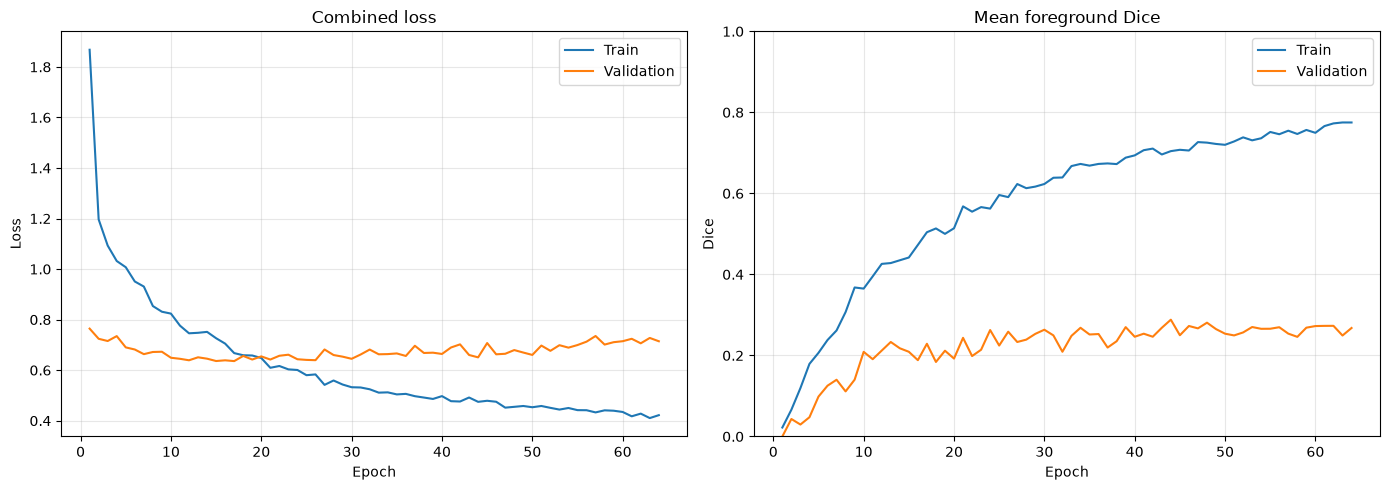

In [26]:
history_df = pd.read_csv(history_path)

required_columns = [
    "epoch",
    "train_loss",
    "val_loss",
    "train_mean_foreground_dice",
    "val_mean_foreground_dice",
]

missing = [column for column in required_columns if column not in history_df.columns]
if missing:
    raise KeyError(
        f"Missing columns: {missing}\n"
        f"Available columns: {history_df.columns.tolist()}"
    )

figure, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation")
axes[0].set_title("Combined loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    history_df["epoch"],
    history_df["train_mean_foreground_dice"],
    label="Train",
)
axes[1].plot(
    history_df["epoch"],
    history_df["val_mean_foreground_dice"],
    label="Validation",
)
axes[1].set_title("Mean foreground Dice")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 25. Load the best checkpoint and evaluate the test set

In [27]:
best_checkpoint = load_checkpoint(
    best_path,
    load_optimizer=False,
    strict=True,
)

model.eval()

test_metrics = run_epoch(
    model=model,
    loader=test_loader,
    training=False,
    optimizer=None,
    scheduler=None,
    scaler=scaler,
)

print("TEST SUMMARY")
for key in (
    "loss",
    "mean_foreground_dice",
    "mean_foreground_iou",
    "mean_foreground_precision",
    "mean_foreground_recall",
    "weighted_foreground_dice",
):
    print(f"{key}: {test_metrics[key]:.4f}")

test_per_class = test_metrics["per_class_metrics"]
test_per_class.to_csv(
    OUTPUT_ROOT / "test_per_class_metrics.csv",
    index=False,
)

display(
    test_per_class[
        [
            "class_id",
            "class_name",
            "support_pixels",
            "predicted_pixels",
            "dice",
            "iou",
            "precision",
            "recall",
        ]
    ].round(4)
)

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL torch.torch_version.TorchVersion was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torch.torch_version.TorchVersion])` or the `torch.serialization.safe_globals([torch.torch_version.TorchVersion])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load 

## 26. Per-sample and per-class HD95 evaluation

In [ ]:
@torch.no_grad()
def evaluate_hd95(
    model: nn.Module,
    loader: DataLoader,
) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []

    model.eval()

    for batch in tqdm(loader, desc="HD95"):
        images = batch["image"].to(DEVICE, non_blocking=True).float()
        targets = batch["mask"].cpu().numpy()
        sample_ids = batch["sample_id"]

        amp_enabled = scaler.is_enabled() and DEVICE.type == "cuda"

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16 if DEVICE.type == "cuda" else torch.bfloat16,
            enabled=amp_enabled,
        ):
            logits = extract_logits(model(images))

        predictions = torch.argmax(logits, dim=1).cpu().numpy()

        for sample_id, prediction, target in zip(
            sample_ids,
            predictions,
            targets,
        ):
            for class_id in range(1, CFG.num_classes):
                if not np.any(target == class_id) and not np.any(prediction == class_id):
                    continue

                rows.append(
                    {
                        "sample_id": sample_id,
                        "class_id": class_id,
                        "class_name": CLASS_NAMES[class_id],
                        "hd95_pixels": hd95_binary(
                            prediction == class_id,
                            target == class_id,
                        ),
                    }
                )

    return pd.DataFrame(rows)


hd95_report = evaluate_hd95(model, test_loader)
hd95_report.to_csv(OUTPUT_ROOT / "test_hd95_per_sample_class.csv", index=False)

finite_hd95 = hd95_report[np.isfinite(hd95_report["hd95_pixels"])]

hd95_summary = (
    finite_hd95.groupby(["class_id", "class_name"])["hd95_pixels"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

failure_counts = (
    hd95_report.assign(complete_failure=np.isinf(hd95_report["hd95_pixels"]))
    .groupby(["class_id", "class_name"])["complete_failure"]
    .sum()
    .reset_index(name="complete_failure_count")
)

hd95_summary = hd95_summary.merge(
    failure_counts,
    on=["class_id", "class_name"],
    how="outer",
)

display(hd95_summary)

## 27. Visualize biomarker predictions

In [ ]:
def prepare_image_for_display(
    image_tensor: torch.Tensor,
    mean: float = 0.5,
    std: float = 0.5,
) -> Tuple[np.ndarray, Optional[str]]:
    image = image_tensor.detach().cpu().float().numpy()
    image = np.transpose(image, (1, 2, 0))
    image = np.clip(image * std + mean, 0.0, 1.0)

    if image.shape[2] == 1 or np.allclose(image[..., 0], image[..., 1]):
        return image[..., 0], "gray"

    return image, None


def labels_in_mask(mask: np.ndarray) -> str:
    class_ids = [
        int(class_id)
        for class_id in np.unique(mask)
        if int(class_id) != 0
    ]

    if not class_ids:
        return "No foreground biomarker"

    return ", ".join(CLASS_NAMES[class_id] for class_id in class_ids)


@torch.no_grad()
def show_model_predictions(
    model: nn.Module,
    dataset: Dataset,
    n: int = 4,
    seed: int = 42,
) -> None:
    if len(dataset) == 0:
        print("Dataset is empty.")
        return

    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), k=min(n, len(dataset)))

    cmap = plt.get_cmap("tab20", CFG.num_classes)
    norm = BoundaryNorm(np.arange(-0.5, CFG.num_classes + 0.5), cmap.N)

    figure, axes = plt.subplots(
        len(indices),
        5,
        figsize=(22, 4.8 * len(indices)),
        squeeze=False,
    )

    displayed_classes: Set[int] = set()
    model.eval()

    for row, index in enumerate(indices):
        item = dataset[index]

        image_tensor = item["image"]
        target = item["mask"].cpu().numpy().astype(np.int64)

        model_input = image_tensor.unsqueeze(0).to(DEVICE).float()

        amp_enabled = scaler.is_enabled() and DEVICE.type == "cuda"

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16 if DEVICE.type == "cuda" else torch.bfloat16,
            enabled=amp_enabled,
        ):
            logits = extract_logits(model(model_input))

        probabilities = torch.softmax(logits.float(), dim=1)
        confidence, prediction = probabilities.max(dim=1)

        prediction = prediction[0].cpu().numpy().astype(np.int64)
        confidence = confidence[0].cpu().numpy()

        image, image_cmap = prepare_image_for_display(image_tensor)

        target_overlay = np.ma.masked_where(target == 0, target)
        prediction_overlay = np.ma.masked_where(prediction == 0, prediction)

        displayed_classes.update(
            int(class_id)
            for class_id in np.unique(target)
            if int(class_id) != 0
        )
        displayed_classes.update(
            int(class_id)
            for class_id in np.unique(prediction)
            if int(class_id) != 0
        )

        predicted_foreground = prediction > 0
        mean_confidence = (
            float(confidence[predicted_foreground].mean())
            if predicted_foreground.any()
            else float(confidence.mean())
        )

        axes[row, 0].imshow(image, cmap=image_cmap)
        axes[row, 0].set_title(
            f"CT image\n{item['sample_id']}\nPatient: {item['patient_id']}"
        )

        axes[row, 1].imshow(
            target,
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
        )
        axes[row, 1].set_title("Ground truth\n" + labels_in_mask(target))

        axes[row, 2].imshow(
            prediction,
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
        )
        axes[row, 2].set_title(
            "Prediction\n"
            + labels_in_mask(prediction)
            + f"\nMean confidence: {mean_confidence:.3f}"
        )

        axes[row, 3].imshow(image, cmap=image_cmap)
        axes[row, 3].imshow(
            target_overlay,
            cmap=cmap,
            norm=norm,
            alpha=0.50,
            interpolation="nearest",
        )
        axes[row, 3].set_title("Ground-truth overlay")

        axes[row, 4].imshow(image, cmap=image_cmap)
        axes[row, 4].imshow(
            prediction_overlay,
            cmap=cmap,
            norm=norm,
            alpha=0.50,
            interpolation="nearest",
        )
        axes[row, 4].set_title("Prediction overlay")

        for axis in axes[row]:
            axis.axis("off")

    legend_handles = [
        Patch(
            facecolor=cmap(class_id),
            label=f"{class_id}: {CLASS_NAMES[class_id]}",
        )
        for class_id in sorted(displayed_classes)
        if 0 < class_id < CFG.num_classes
    ]

    if legend_handles:
        figure.legend(
            handles=legend_handles,
            loc="lower center",
            ncol=3,
            bbox_to_anchor=(0.5, 0.0),
            fontsize=9,
        )
        plt.tight_layout(rect=(0, 0.10, 1, 1))
    else:
        plt.tight_layout()

    plt.show()


show_model_predictions(model, test_dataset, n=4, seed=CFG.seed)

## 28. Export a deployment checkpoint and run metadata

In [ ]:
deployment_payload = {
    "model_state_dict": unwrap_model(model).state_dict(),
    "architecture": {
        "name": "DeepLabV3Plus",
        "backbone": "resnet50",
        "image_size": CFG.image_size,
        "input_channels": CFG.input_channels,
        "num_classes": CFG.num_classes,
        "backbone_pretrained_requested": CFG.backbone_pretrained,
        "backbone_pretrained_loaded": (
            unwrap_model(model).backbone_pretrained_loaded
        ),
        "freeze_backbone_batchnorm": CFG.freeze_backbone_batchnorm,
        "aspp_channels": CFG.aspp_channels,
        "aspp_rates": list(CFG.aspp_rates),
        "low_level_channels": CFG.low_level_channels,
        "decoder_channels": CFG.decoder_channels,
        "classifier_dropout": CFG.classifier_dropout,
    },
    "preprocessing": {
        "resize": [CFG.image_size, CFG.image_size],
        "normalization_mean": [0.5, 0.5, 0.5],
        "normalization_std": [0.5, 0.5, 0.5],
        "mask_class_mapping": CLASS_NAMES,
    },
    "best_validation_dice": best_checkpoint.get("best_val_dice"),
    "test_summary": {
        key: value
        for key, value in test_metrics.items()
        if isinstance(value, (int, float, np.integer, np.floating))
    },
}

deployment_path = OUTPUT_ROOT / "deeplabv3plus_stroke_deployment.pt"
save_checkpoint_atomic(deployment_payload, deployment_path)

run_metadata = {
    "architecture": "DeepLabV3Plus",
    "backbone": "resnet50",
    "device": str(DEVICE),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "torch_version": torch.__version__,
    "torchvision_version": __import__("torchvision").__version__,
    "cuda_version": torch.version.cuda,
    "config": asdict(CFG),
}

with (OUTPUT_ROOT / "run_metadata.json").open("w", encoding="utf-8") as file:
    json.dump(run_metadata, file, indent=2)

print("Saved deployment checkpoint:", deployment_path)
print("Saved run metadata:", OUTPUT_ROOT / "run_metadata.json")

## 29. Final checks

Before accepting the model:

- Confirm every intended class has positive training examples.
- Select the best checkpoint using mean foreground validation Dice, not training loss.
- Review per-class Dice, precision, recall, and HD95.
- Inspect false positives and complete misses for the rare classes.
- Keep the test set untouched until final model selection.
- Document the patient-level split manifest, ResNet-50 initialization, and DeepLabV3+ configuration.
- Remember that class-aware augmentation improves exposure but does not create new biological diversity.